<a href="https://colab.research.google.com/github/deviapujiastuti/image-processing/blob/main/ip_tugas_pertemuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving ip.jpg to ip.jpg


kode diatas untuk mengupload gambar yang akan diolah

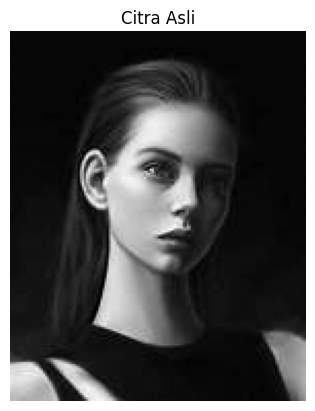

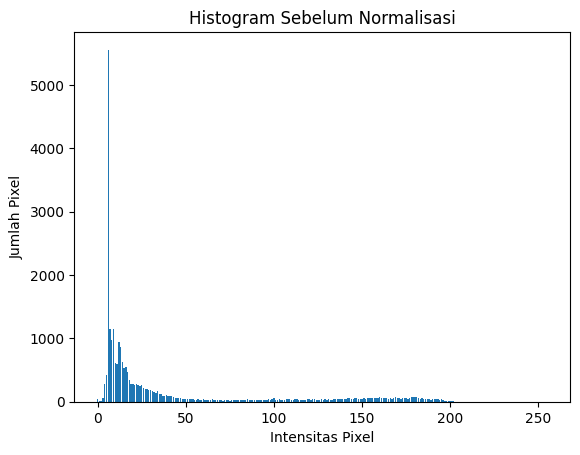

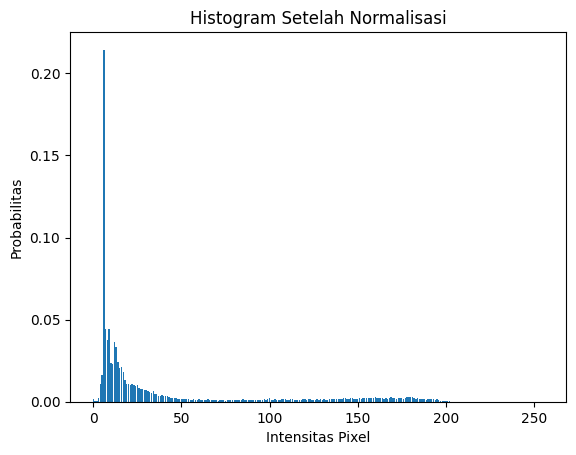

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# membaca citra dalam grayscale
img = cv2.imread('/content/ip.jpg', 0)

# ukuran citra
height, width = img.shape
total_pixel = height * width

# membuat array histogram
hist = np.zeros(256)

# menghitung histogram secara manual
for i in range(height):
    for j in range(width):
        intensity = img[i,j]
        hist[intensity] += 1

# normalisasi histogram
hist_norm = hist / total_pixel

# menampilkan citra, menampilkan histogram sebelum dan sesuadah normalisasi
plt.imshow(img, cmap='gray')
plt.title("Citra Asli")
plt.axis('off')
plt.show()

plt.bar(range(256), hist)
plt.title("Histogram Sebelum Normalisasi")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")
plt.show()

plt.bar(range(256), hist_norm)
plt.title("Histogram Setelah Normalisasi")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Probabilitas")
plt.show()

ada beberapa library yang dibutuhkan disini ada mengimport 3 library : OpenCV (cv2) digunakan untuk membaca citra, NumPy digunakan untuk membuat dan mengolah array histogram, sedangkan Matplotlib digunakan untuk menampilkan gambar dan grafik histogram.

untuk mengetahui tinggi dan lebar citra, lalu membuat sebuah array berukuran 256 elemen yang digunakan untuk menyimpan jumlah kemunculan setiap nilai intensitas piksel (0–255) dimana walnya semua nilai diisi dengan 0.

Program melakukan perulangan untuk membaca setiap piksel pada citra. Nilai intensitas piksel tersebut kemudian digunakan sebagai indeks pada array histogram, sehingga jumlah kemunculan setiap intensitas dapat dihitung. Lalu dilakukan normalisasi histogram dengan cara membagi setiap nilai histogram dengan jumlah total piksel. Hasilnya adalah nilai probabilitas kemunculan setiap intensitas piksel. baru ditampilkan dan hasilnya seperti diatas

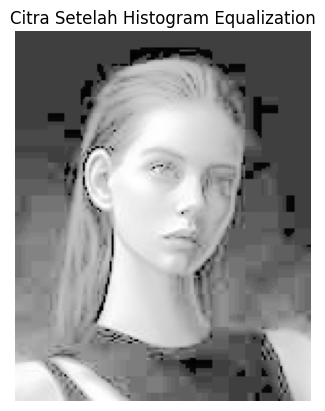

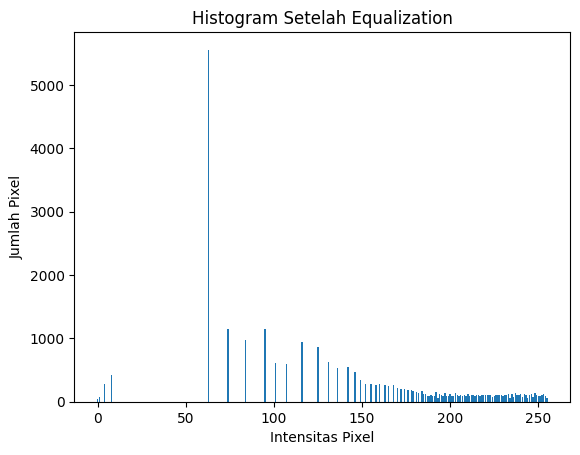

In [4]:
# menghitung probabilitas kumulatif (CDF)
cdf = np.zeros(256)
cdf[0] = hist_norm[0]

for i in range(1,256):
    cdf[i] = cdf[i-1] + hist_norm[i]

transform = np.round(cdf * 255)

# membuat citra hasil histogram equalization
equalized_img = np.zeros_like(img)

for i in range(height):
    for j in range(width):
        equalized_img[i,j] = transform[img[i,j]]

# menampilkan citra hasil equalization
plt.imshow(equalized_img, cmap='gray')
plt.title("Citra Setelah Histogram Equalization")
plt.axis('off')
plt.show()

# menghitung histogram citra hasil equalization
hist_eq = np.zeros(256)

for i in range(height):
    for j in range(width):
        hist_eq[equalized_img[i,j]] += 1

# menampilkan histogram setelah equalization
plt.bar(range(256), hist_eq)
plt.title("Histogram Setelah Equalization")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")
plt.show()

histogram equalization itu dilakukan untuk meningkatkan kontras citra. Program terlebih dahulu menghitung probabilitas kumulatif (CDF) dari histogram yang telah dinormalisasi dengan menjumlahkan nilai probabilitas setiap intensitas secara bertahap. Nilai CDF tersebut kemudian digunakan untuk membuat transformasi intensitas baru dengan mengalikannya dengan 255 sehingga diperoleh nilai piksel yang baru. Setelah itu setiap piksel pada citra asli diganti dengan nilai transformasi tersebut sehingga terbentuk citra hasil histogram equalization. Terakhir, program menghitung dan menampilkan kembali histogram dari citra hasil untuk melihat perubahan distribusi intensitas piksel yang biasanya menjadi lebih merata dan meningkatkan kontras gambar.